In [52]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten 

In [53]:
(X_train , y_train ) , (X_test , y_test) = keras.datasets.mnist.load_data()

In [54]:
X_train.shape

(60000, 28, 28)

In [55]:
X_train[0].shape

(28, 28)

In [56]:
X_test.shape

(10000, 28, 28)

In [57]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [58]:
y_test

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

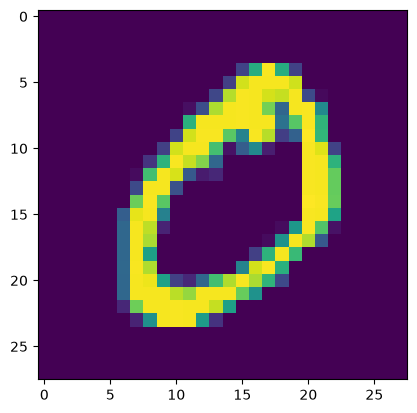

In [59]:
import matplotlib.pyplot as plt
plt.imshow(X_train[1])

In [60]:
X_train = X_train/255
X_test = X_test/255

In [61]:
model = Sequential()

model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(10,activation='softmax'))

/opt/anaconda3/envs/tensorflow_env/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [62]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,938 (409.91 KB)

 Trainable params: 104,938 (409.91 KB)

 Non-trainable params: 0 (0.00 B)

In [63]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [64]:
history =model.fit(X_train,y_train,epochs=25,validation_split=0.2)

Epoch 1/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9186 - loss: 0.2797 - val_accuracy: 0.9579 - val_loss: 0.1424
Epoch 2/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 731us/step - accuracy: 0.9653 - loss: 0.1148 - val_accuracy: 0.9670 - val_loss: 0.1120
Epoch 3/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 735us/step - accuracy: 0.9759 - loss: 0.0810 - val_accuracy: 0.9686 - val_loss: 0.1086
Epoch 4/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 905us/step - accuracy: 0.9818 - loss: 0.0601 - val_accuracy: 0.9708 - val_loss: 0.0963
Epoch 5/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 740us/step - accuracy: 0.9854 - loss: 0.0479 - val_accuracy: 0.9739 - val_loss: 0.0952
Epoch 6/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 720us/step - accuracy: 0.9891 - loss: 0.0366 - val_accuracy: 0.9742 - val_loss: 0.0977
Epoch 7/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 725us/step - accuracy: 0.9904 - loss: 0.0310 - val_accuracy: 0.9741 - val_loss: 0.1011
Epoch 8/25
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 848us/step - accuracy: 0.9915 - l

In [65]:
y_prob=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 311us/step


In [66]:
y_pred=y_prob.argmax(axis=1)

In [67]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9731

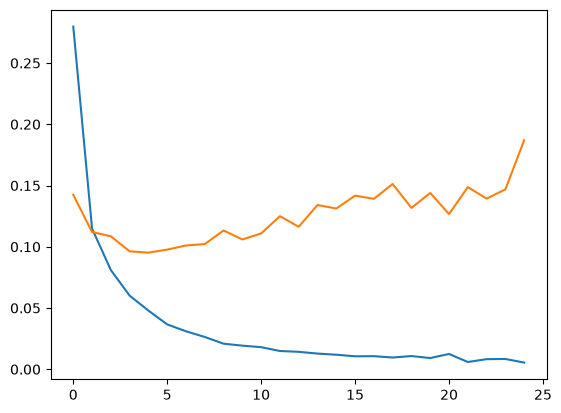

In [68]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

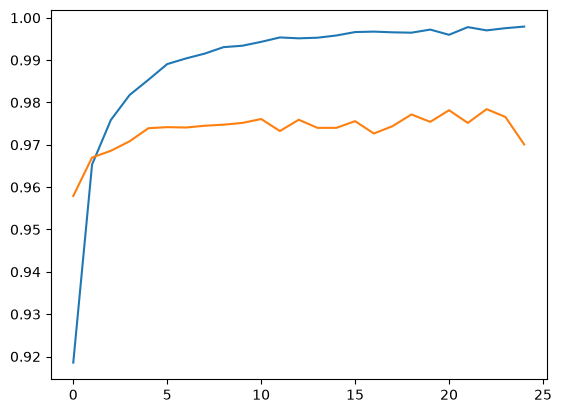

In [70]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

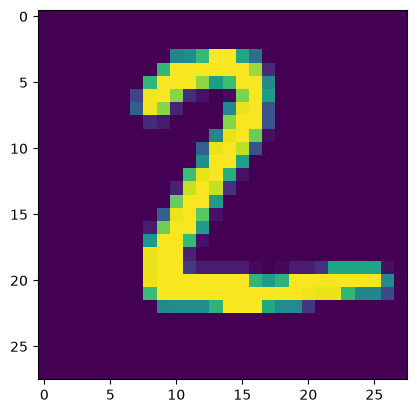

In [74]:
plt.imshow(X_test[1])

In [75]:
model.predict(X_test[1].reshape(1,28,28)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


array([2])